# Task 1 — LLM-Powered Equity Research Assistant

**CDAZZDEV Senior Machine Learning Engineer Assessment**

This notebook runs the complete Task 1 pipeline end to end against live market data.

| Section | Deliverable | Marks |
|---|---|---|
| 1A | OHLCV fetch, five indicators from first principles, news retrieval, summary dictionary | 60 |
| 1B | Per-headline sentiment JSON, LLM signal reasoning, Pydantic validation, prompt separation | 40 |
| Bonus | One-page rendered research brief with embedded chart | +5 |

**Architecture.** All logic lives in `task1_financial/src/` as importable modules; this
notebook is a thin execution harness. That is deliberate — logic buried in notebook cells
cannot be unit-tested, and Section 2 of the brief says every part of the submission must be
defensible. Section 2 of this notebook runs the actual test suite so you can see the
indicator maths verified against an independent implementation before any of it is used.

**Reproducibility.** Every run prints a manifest: which provider and model served the
request, and which prompt versions were used.

## 0 · Environment setup

`yfinance` is pinned to a minimum rather than an exact version because its news payload
schema changes between releases; `data_pipeline._news_from_yfinance` handles both the old
flat shape and the newer nested `content` shape.

In [1]:
%%capture
!pip install -q "yfinance>=0.2.40" "openai>=1.40" "pydantic>=2.7" jinja2 matplotlib pandas numpy requests

In [2]:
import os, sys, json, logging, warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)-7s %(name)s | %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

# --- Locate the repository -------------------------------------------------
# On Colab: clone it. Locally (VS Code): the notebook already sits inside it.
REPO = "CDAZZDEV-MLE-UDITH-WEERASINGHE"
if not Path(REPO).exists() and not (Path.cwd().name == REPO or (Path.cwd() / "common").exists()):
    !git clone -q https://github.com/UdithWeerasinghe/CDAZZDEV-MLE-UDITH-WEERASINGHE.git
    %cd {REPO}
elif Path(REPO).exists() and Path.cwd().name != REPO:
    %cd {REPO}

ROOT = Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "task1_financial" / "src")]
print("Repository root:", ROOT)
print("Contents:", sorted(p.name for p in ROOT.iterdir() if not p.name.startswith(".")))

Repository root: C:\projects\CDAZZDEV\CDAZZDEV-MLE-UDITH-WEERASINGHE\CDAZZDEV-MLE-UDITH-WEERASINGHE
Contents: ['CITATIONS.md', 'LICENSE', 'README.md', 'REFLECTION.md', 'SETUP.md', 'common', 'requirements.txt', 'task1_financial', 'task2_genai', 'task3_agentic']


### API keys

Keys are read from Colab **Secrets** (the key icon in the left sidebar), never from a code
cell. Add at least one of `GROQ_API_KEY` or `OPENROUTER_API_KEY` and toggle *Notebook access* on.

Section 2.3 of the brief lists a hardcoded key as an automatic disqualification, so
`common.llm_client.get_secret()` has no code path that accepts a literal key — it resolves
environment → Colab Secrets → interactive prompt, in that order.

* Groq (recommended, free, no card): https://console.groq.com/keys
* OpenRouter (fallback, free models): https://openrouter.ai/keys

In [3]:
from common.llm_client import get_secret

for name in ("GROQ_API_KEY", "OPENROUTER_API_KEY", "GEMINI_API_KEY"):
    value = get_secret(name)
    print(f"{name:<20} {'configured (' + value[:6] + '…)' if value else 'NOT SET'}")

if not (os.environ.get("GROQ_API_KEY") or os.environ.get("OPENROUTER_API_KEY")
        or os.environ.get("GEMINI_API_KEY")):
    raise SystemExit(
        "Set at least one of GROQ_API_KEY, OPENROUTER_API_KEY or "
        "GEMINI_API_KEY in Colab Secrets, then re-run this cell."
    )

GROQ_API_KEY         configured (gsk_dL…)
OPENROUTER_API_KEY   configured (sk-or-…)
GEMINI_API_KEY       configured (AQ.Ab8…)


## 1 · Configuration

The ticker is the only thing you need to change. Nothing downstream is hardcoded to it,
and there are **no literal date strings anywhere** — the window is expressed in years and
resolved against `pd.Timestamp.now()` at call time.

In [4]:
TICKER          = "NVDA"     # Try AAPL, MSFT, JPM, TSLA, or a non-US symbol like BARC.L
LOOKBACK_YEARS  = 2          # Brief requires a minimum of two years
MIN_HEADLINES   = 10         # Brief requires at least ten

OUTPUT_DIR = ROOT / "task1_financial" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Analysing {TICKER} over {LOOKBACK_YEARS}y, targeting >= {MIN_HEADLINES} headlines.")

Analysing NVDA over 2y, targeting >= 10 headlines.


## 2 · Verifying the indicator maths *before* using it

The 25-mark criterion is "all five indicators computed correctly from first principles."
Asserting that in prose is worth nothing, so the test suite verifies each indicator against
an **independent pure-Python reference implementation** — explicit loops over lists, no
pandas, no numpy. Two independent derivations of the same textbook formula agreeing to
1e-9 is real evidence; verifying pandas code with more pandas code sharing the same
assumptions is not.

Three correctness decisions this catches, each of which the common implementation gets wrong:

1. **RSI uses Wilder's smoothing, not a rolling mean.** `gain.rolling(14).mean()` is
   *Cutler's* RSI — a different indicator. The test measures the divergence.
2. **MACD uses `adjust=False` EMAs.** pandas defaults to `adjust=True`, which puts the
   signal-line crossovers in the wrong places.
3. **Bollinger Bands use the population σ (`ddof=0`).** pandas defaults to `ddof=1`, which
   inflates a 2σ band by ~2.6%.

In [5]:
!python task1_financial/tests/test_indicators.py


Running 14 verification tests against independent references

test_bollinger_uses_population_std
  PASS Bollinger upper (ddof=0)           n= 581  max_dev=2.515e-12
  PASS Bollinger middle                   n= 581  max_dev=5.684e-14
  PASS Bollinger lower (ddof=0)           n= 581  max_dev=2.572e-12
  PASS ddof=1 would inflate sigma by      2.60%

test_compute_all_does_not_mutate_input
  PASS Input frame not mutated            5 columns unchanged

test_ema_matches_recursive_reference
  PASS EMA-12                             n= 589  max_dev=0.000e+00
  PASS EMA-26                             n= 575  max_dev=0.000e+00
  PASS EMA-9                              n= 592  max_dev=0.000e+00

test_invalid_parameters_rejected
  PASS Invalid parameter rejection        5 cases

test_macd_components_and_identity
  PASS MACD line                          n= 575  max_dev=0.000e+00
  PASS MACD histogram identity            max_dev=0.000e+00

test_missing_data_does_not_raise
  PASS NaN gap handling  

In [6]:
!python task1_financial/tests/test_schemas.py


Running 11 schema/validator tests

test_confidence_weighted_aggregation
  PASS Confidence-weighted aggregation        score=-0.188 despite 2-1 positive count

test_decimals_do_not_inflate_sentence_count
  PASS Decimals not counted as sentences      3 sentences detected

test_degenerate_batch_detected
  PASS Degenerate batch detection             rubber-stamp flagged, varied batch clean

test_fallback_signal_passes_its_own_validator
  PASS Fallback signal self-validates         Buy @ conf 0.55, 4 sentences

test_headline_sentiment_rejects_non_answers
  PASS Non-answer brief_reason rejected       3 cases, 1 valid accepted

test_out_of_range_values_rejected
  PASS Range and enum enforcement             3 cases

test_single_indicator_rejected
  PASS Single indicator only                  rejected: justification: Value error, justification references 1 distinct indicator(s) (['rsi']); at

test_synthesis_is_accepted
  PASS Genuine synthesis accepted             4 sentences, 6 indicators

te

## 3 · Task 1A — data pipeline

Fetches split- and dividend-adjusted OHLCV (`auto_adjust=True`, a correctness requirement:
an unadjusted series puts a −50% single-bar gap at a stock split, which detonates RSI and
drags the SMA-200 for 200 sessions), computes all five indicators, retrieves news through
a four-source fallback chain, and assembles the summary dictionary.

In [7]:
from data_pipeline import build_equity_dataset

equity = build_equity_dataset(TICKER, lookback_years=LOOKBACK_YEARS, min_headlines=MIN_HEADLINES)

print(f"\nSessions retrieved : {len(equity.prices)}")
print(f"Date range         : {equity.prices.index[0].date()} → {equity.prices.index[-1].date()}")
print(f"Headlines retrieved: {len(equity.news)}")
if equity.warnings:
    print("\nPipeline warnings (degradations, not failures):")
    for w in equity.warnings:
        print("  •", w)

INFO    data_pipeline | Fetching NVDA from 2024-08-14 to 2026-09-13.


INFO    data_pipeline | Retrieved 521 sessions for NVDA (2024-08-14 to 2026-09-11).


INFO    data_pipeline | News source google_rss contributed 25 unique headlines (total 25).



Sessions retrieved : 521
Date range         : 2024-08-14 → 2026-09-11
Headlines retrieved: 25


### 3.1 Indicator output

The tail of the enriched frame. Note the warm-up NaNs are never forward-filled — a
fabricated 200-day SMA on day 3 is a silent lie that would propagate into the signal.

In [8]:
import pandas as pd
pd.set_option("display.width", 200, "display.max_columns", 40, "display.precision", 3)

cols = ["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_signal", "macd_hist",
        "bb_lower", "bb_middle", "bb_upper", "bb_pct_b", "volatility_30d"]
display(equity.prices[cols].tail(8))

print("\nWarm-up (first valid observation per indicator):")
for c in cols[1:]:
    first = equity.prices[c].first_valid_index()
    pos = equity.prices.index.get_loc(first) if first is not None else None
    print(f"  {c:<16} row {pos:>4}  ({first.date() if first is not None else 'never'})")

,Close,sma_50,sma_200,rsi_14,macd,macd_signal,macd_hist,bb_lower,bb_middle,bb_upper,bb_pct_b,volatility_30d
Date,,,,,,,,,,,,
2026-09-01,217.197,208.564,195.705,51.873,2.286,2.668,-0.382,208.639,218.785,228.931,0.422,0.448
2026-09-02,224.159,209.051,195.894,56.672,2.665,2.667,-0.003,208.630,219.044,229.458,0.746,0.453
2026-09-03,228.195,209.639,196.086,59.211,3.253,2.784,0.468,208.368,219.516,230.664,0.889,0.452
2026-09-04,230.103,210.331,196.306,60.393,3.829,2.993,0.835,207.887,219.836,231.785,0.930,0.451
2026-09-08,225.478,210.994,196.529,56.147,3.867,3.168,0.699,208.113,220.245,232.377,0.716,0.426
2026-09-09,223.420,211.568,196.715,54.317,3.689,3.272,0.417,208.427,220.553,232.679,0.618,0.428
2026-09-10,218.360,211.938,196.906,50.001,3.104,3.239,-0.134,208.215,220.279,232.343,0.420,0.419
2026-09-11,218.290,212.356,197.105,49.942,2.605,3.112,-0.507,208.053,219.941,231.829,0.431,0.414



Warm-up (first valid observation per indicator):
  sma_50           row   49  (2024-10-23)
  sma_200          row  199  (2025-06-02)
  rsi_14           row   14  (2024-09-04)
  macd             row   25  (2024-09-19)
  macd_signal      row   33  (2024-10-01)
  macd_hist        row   33  (2024-10-01)
  bb_lower         row   19  (2024-09-11)
  bb_middle        row   19  (2024-09-11)
  bb_upper         row   19  (2024-09-11)
  bb_pct_b         row   19  (2024-09-11)
  volatility_30d   row   30  (2024-09-26)


### 3.2 News retrieval

The chain tries yfinance → Yahoo RSS → Google News RSS → NewsAPI, deduplicating by
normalised title and stopping as soon as the minimum is met. A single source is not
enough: yfinance's payload shape changed between releases and any one feed can return
fewer than ten items on a quiet day.

In [9]:
print(f"{len(equity.news)} unique headlines from "
      f"{len({n.source for n in equity.news})} distinct source(s)\n")
for i, item in enumerate(equity.news, 1):
    print(f"{i:>2}. [{item.source[:22]:<22}] {item.headline[:96]}")

25 unique headlines from 1 distinct source(s)

 1. [Google News RSS       ] Is Micron Stock the Next Nvidia? The Answer May Shock Investors. - finance.yahoo.com
 2. [Google News RSS       ] It's About To Get Worse For Nvidia (NASDAQ:NVDA) - Seeking Alpha
 3. [Google News RSS       ] Foxconn Just Delivered a Major Bullish Signal for Nvidia Stock - Barchart.com
 4. [Google News RSS       ] Analyst sets jaw-dropping Nvidia price target - thestreet.com
 5. [Google News RSS       ] Ahara Advisors LLC Grows Stock Holdings in NVIDIA Corporation $NVDA - MarketBeat
 6. [Google News RSS       ] Nvidia Just Handed Its 1.3 Million-Part Supply Chain to a Stock Cramer Called Ice Cold - 24/7 Wa
 7. [Google News RSS       ] Jim Cramer Says He’s ‘Not Going to Give Up on Nvidia’ Stock: Here’s His Suggestion for CEO Jense
 8. [Google News RSS       ] Nvidia vs. AMD: Elon Musk Picked a Side on the SpaceX Earnings Call - finance.yahoo.com
 9. [Google News RSS       ] Jim Cramer Discussed The Contradictions

### 3.3 Summary dictionary

Every required field, and every value is either a finite number or an explicit `None` —
never `NaN`. That matters: handing a model the literal string `NaN` is a reliable way to
make it invent a value.

52-week high/low and YTD are computed from the price series we already hold rather than
read from `Ticker.info`, which is an undocumented scraped endpoint that returns `{}` under
load. Deriving them is both more reliable and independently checkable.

In [10]:
print(json.dumps(equity.summary, indent=2, default=str))

{
  "ticker": "NVDA",
  "company_name": "NVIDIA Corporation",
  "sector": "Technology",
  "industry": "Semiconductors",
  "currency": "USD",
  "as_of": "2026-09-11",
  "sessions_analysed": 521,
  "current_price": 218.29,
  "fifty_two_week_high": 235.2,
  "fifty_two_week_low": 164.79,
  "pct_below_52w_high": -7.19,
  "pct_above_52w_low": 32.46,
  "ytd_return_pct": 17.32,
  "pe_ratio": 27.63,
  "pe_source": "yfinance.trailingPE",
  "market_cap": 5271048421376.0,
  "sma_50": 212.36,
  "sma_200": 197.11,
  "rsi_14": 49.94,
  "macd": 2.6048,
  "macd_signal": 3.1119,
  "macd_histogram": -0.5071,
  "bollinger_upper": 231.83,
  "bollinger_middle": 219.94,
  "bollinger_lower": 208.05,
  "bollinger_pct_b": 0.4306,
  "annualised_volatility_30d": 0.4139,
  "momentum_signal": "bullish",
  "momentum_score": 0.401,
  "momentum_components": {
    "trend_regime": 1.0,
    "price_vs_sma50": 0.5588573663425259,
    "macd_histogram": -0.2322968117400163,
    "rsi": -0.00291059358250223,
    "bollinger_pos

## 4 · Task 1B — LLM sentiment and signal reasoning

The client is provider-agnostic with automatic failover. It queries each provider's
`/models` endpoint at construction time and picks the highest-ranked model actually
served, rather than hardcoding an ID — `llama3-70b-8192`, the model the brief's tool table
implies, is already deprecated on Groq. Hardcoding it means the reviewer's run fails.

In [11]:
from common.llm_client import LLMClient, Tier

llm = LLMClient(tier=Tier.REASONING, temperature=0.2)
print("Run manifest:")
print(json.dumps(llm.describe(), indent=2))

INFO    httpx2 | HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/openai/models "HTTP/1.1 200 OK"


INFO    common.llm_client | Provider gemini ready with model gemini-3.6-flash.


INFO    httpx2 | HTTP Request: GET https://api.groq.com/openai/v1/models "HTTP/1.1 200 OK"


INFO    common.llm_client | Provider groq ready with model openai/gpt-oss-120b.


INFO    httpx2 | HTTP Request: GET https://openrouter.ai/api/v1/models "HTTP/1.1 200 OK"


INFO    common.llm_client | Provider openrouter ready with model nvidia/nemotron-3-super-120b-a12b:free.


Run manifest:
{
  "tier": "reasoning",
  "providers": [
    {
      "provider": "gemini",
      "model": "gemini-3.6-flash",
      "base_url": "https://generativelanguage.googleapis.com/v1beta/openai/"
    },
    {
      "provider": "groq",
      "model": "openai/gpt-oss-120b",
      "base_url": "https://api.groq.com/openai/v1"
    },
    {
      "provider": "openrouter",
      "model": "nvidia/nemotron-3-super-120b-a12b:free",
      "base_url": "https://openrouter.ai/api/v1"
    }
  ]
}


### 4.1 Per-headline sentiment

Headlines are classified in batches of 8 (large enough to be token-efficient, small enough
that the model rarely drops items), then **reconciled**: any headline missing from the
response is retried individually, and anything still missing is recorded as
neutral/0.0-confidence with an explicit failure reason rather than dropped. An aggregate
computed over a silently truncated sample is a wrong number that looks right.

In [12]:
from llm_analysis import analyse

result = analyse(llm, equity, failure_log_path=OUTPUT_DIR / "validation_failures.jsonl")

print(f"\n{'Sentiment':<10} {'Conf':<6} Headline / reason")
print("─" * 118)
for s in result.headline_sentiments:
    print(f"{s.sentiment.value:<10} {s.confidence:<6.2f} {s.headline[:92]}")
    print(f"{'':<17} └─ {s.brief_reason[:92]}")

INFO    httpx2 | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/openai/chat/completions "HTTP/1.1 200 OK"


WARNING common.llm_client | JSON parse failure (attempt 1): Unterminated string starting at: line 7 column 23 (char 207)


INFO    httpx2 | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/openai/chat/completions "HTTP/1.1 200 OK"


INFO    httpx2 | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/openai/chat/completions "HTTP/1.1 200 OK"


INFO    httpx2 | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/openai/chat/completions "HTTP/1.1 200 OK"


...

INFO    httpx2 | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/openai/chat/completions "HTTP/1.1 200 OK"


WARNING common.llm_client | JSON parse failure (attempt 3): Unterminated string starting at: line 1 column 64 (char 63)


WARNING llm_analysis | [trading_signal] attempt 3 failed: ValueError: Model did not return valid JSON after 3 attempts: Unterminated string starting at: line 1 column 64 (char 63)


ERROR   llm_analysis | LLM signal failed validation after all attempts; using rules-based fallback.



Sentiment  Conf   Headline / reason
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
neutral    0.85   Is Micron Stock the Next Nvidia? The Answer May Shock Investors. - finance.yahoo.com
                  └─ Mentions Nvidia merely as a comparison benchmark for Micron
negative   0.85   It's About To Get Worse For Nvidia (NASDAQ:NVDA) - Seeking Alpha
                  └─ Expresses a strongly bearish outlook predicting worsening outlook for Nvidia
positive   0.85   Foxconn Just Delivered a Major Bullish Signal for Nvidia Stock - Barchart.com
                  └─ Key manufacturing partner delivered a major bullish signal for Nvidia stock
positive   0.75   Analyst sets jaw-dropping Nvidia price target - thestreet.com
                  └─ Reports a significantly high analyst price target upgrade for Nvidia
neutral    0.80   Ahara Advisors LLC Grows Stock Holdings in NVIDIA Corporation $NVDA - MarketBeat
                 

### 4.2 Aggregate sentiment

Weighted by confidence rather than a plain majority, so a hedged 0.55 classification cannot
outvote a decisive 0.95 one. Unweighted counts are kept alongside so the analyst sees both.

In [13]:
agg = result.aggregate
print(json.dumps(agg.model_dump(mode="json"), indent=2) if agg else "No aggregate produced.")
if agg and agg.degenerate_warning:
    print("\n⚠️  Degenerate batch: one label AND one confidence across all headlines.")
    print("    Usually means the model rubber-stamped the batch instead of reading it.")

{
  "score": 0.1034,
  "label": "neutral",
  "headline_count": 25,
  "positive_count": 5,
  "negative_count": 2,
  "neutral_count": 18,
  "mean_confidence": 0.774,
  "degenerate_warning": false
}


### 4.3 Trading signal

The 15-mark criterion is *"LLM reasons over indicator combinations, not just echoes
values."* That is normally a human judgement. Here it is **enforced in code**: the
`TradingSignal` validator rejects a justification unless it (a) runs 3–5 sentences,
(b) names at least two distinct indicators, and (c) contains relational language
(*confirms, diverges, despite, outweighs*). A model that lists "RSI is 62, MACD is 1.4"
contains no such word and is rejected, handed its own validator error, and asked again.

If it still cannot synthesise after the repair attempts, a deterministic rules-based
signal takes over and the output is **flagged as a fallback**. A degraded but honest
result beats a confident fabrication.

In [14]:
sig = result.signal
print(f"RECOMMENDATION : {sig.recommendation.value}")
print(f"CONFIDENCE     : {sig.confidence:.0%}")
print(f"SOURCE         : {'⚠️  RULES-BASED FALLBACK' if result.signal_is_fallback else 'LLM (validated)'}")
print(f"\nJUSTIFICATION\n{'─' * 78}\n{sig.justification}")
print(f"\nKEY DRIVERS")
for d in sig.key_drivers: print("  •", d)
print("\nRISKS TO THIS VIEW")
for r in sig.risks: print("  •", r)
print(f"\nVALIDATOR REPORT\n{json.dumps(sig.quality_report(), indent=2)}")

RECOMMENDATION : Buy
CONFIDENCE     : 46%
SOURCE         : ⚠️  RULES-BASED FALLBACK

JUSTIFICATION
──────────────────────────────────────────────────────────────────────────────
The mechanical momentum screen returns bullish at a score of +0.40, with the 50-day average sitting above the 200-day. News sentiment confirms that technical picture at a score of +0.10 across 25 headlines. RSI-14 at 49.94 is treated as confirmation only, since the trend regime carries the greater weight in this framework. On balance the blended score of +0.31 supports a Buy stance, though this is a deterministic fallback rather than a reasoned analyst view.

KEY DRIVERS
  • Momentum screen score of +0.40 with SMA-50 above SMA-200
  • News sentiment score of +0.10 across 25 classified headlines

RISKS TO THIS VIEW
  • This is a rules-based fallback produced after LLM validation failed, and carries no qualitative judgement

VALIDATOR REPORT
{
  "sentences": 4,
  "indicators_referenced": [
    "price_action",
   

### 4.4 Validation failures

The brief requires validation failures to be *"caught, logged, and handled gracefully."*
This is the evidence they were. An empty log is a clean run; a populated one shows the
validation layer doing real work — which is the stronger demonstration.

In [15]:
print(f"Failures by stage: {result.failure_summary or 'none — clean run'}\n")
for f in result.validation_failures:
    print(f"[{f.stage}] attempt {f.attempt} — recovered={f.recovered}")
    print(f"   {f.error[:200]}\n")

log_path = OUTPUT_DIR / "validation_failures.jsonl"
if log_path.exists():
    print(f"Persisted to {log_path.relative_to(ROOT)} "
          f"({len(log_path.read_text().strip().splitlines())} entries)")

Failures by stage: {'trading_signal': 3}

[trading_signal] attempt 1 — recovered=False
   ValueError: Model did not return valid JSON after 3 attempts: Unterminated string starting at: line 1 column 64 (char 63)

[trading_signal] attempt 2 — recovered=False
   ValueError: Model did not return valid JSON after 3 attempts: Unterminated string starting at: line 4 column 20 (char 71)

[trading_signal] attempt 3 — recovered=False
   ValueError: Model did not return valid JSON after 3 attempts: Unterminated string starting at: line 1 column 64 (char 63)

Persisted to task1_financial\output\validation_failures.jsonl (3 entries)


## 5 · Bonus — one-page research brief

Self-contained HTML: the chart is an embedded base64 data URI and all CSS is inline, so
the file renders identically from the repository, an email attachment, or a Drive link
with no external requests. A brief that only renders next to its own `/images` folder is
not a deliverable.

The risk disclaimer is rendered by the template rather than passed in, so it cannot be
accidentally omitted.

INFO    report | Brief written to C:\projects\CDAZZDEV\CDAZZDEV-MLE-UDITH-WEERASINGHE\CDAZZDEV-MLE-UDITH-WEERASINGHE\task1_financial\output\NVDA_brief.html (231.5 KB).


HTML     : task1_financial\output\NVDA_brief.html  (232 KB)
Markdown : task1_financial\output\NVDA_brief.md


Sentiment,Conf.,Headline,Why
negative,0.90,Nvidia Stock Slips Overnight: Director Mark Stevens Dumps $640M In Stock Amid AI Testing Capacity Strains - finance.yahoo.com,Large $640M director insider sell combined with capacity strain concerns
neutral,0.90,"Meridian Investment Counsel Inc. Sells 3,900 Shares of NVIDIA Corporation $NVDA - MarketBeat",routine institutional position adjustment involving an immaterial number of shares relative to market cap
neutral,0.85,Is Micron Stock the Next Nvidia? The Answer May Shock Investors. - finance.yahoo.com,Mentions Nvidia merely as a comparison benchmark for Micron

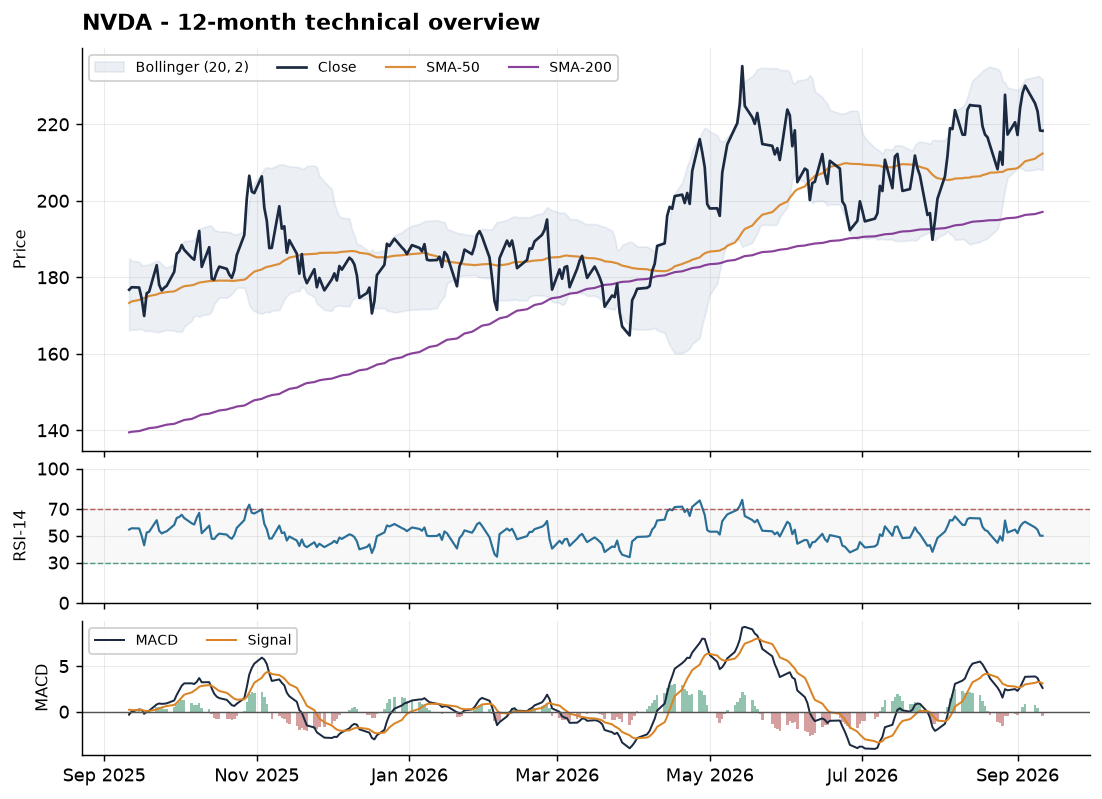

In [16]:
from report import render_html_brief, render_markdown_brief
from IPython.display import HTML, display

html_path = render_html_brief(equity, result, OUTPUT_DIR / f"{TICKER}_brief.html")
md_path   = render_markdown_brief(equity, result, OUTPUT_DIR / f"{TICKER}_brief.md")

print(f"HTML     : {html_path.relative_to(ROOT)}  ({html_path.stat().st_size / 1024:.0f} KB)")
print(f"Markdown : {md_path.relative_to(ROOT)}")

display(HTML(html_path.read_text(encoding="utf-8")))

## 6 · Run manifest

Printed so the reviewer can reproduce exactly this run: which provider and model served
each request, which prompt versions were used, and how many calls it took.

In [17]:
manifest = {
    "ticker": TICKER,
    "lookback_years": LOOKBACK_YEARS,
    "as_of": equity.summary.get("as_of"),
    "sessions_analysed": equity.summary.get("sessions_analysed"),
    "headlines_classified": len(result.headline_sentiments),
    "recommendation": result.signal.recommendation.value,
    "signal_is_fallback": result.signal_is_fallback,
    "validation_failures": result.failure_summary,
    "models": result.model_manifest,
    "prompts": [{"name": p["name"], "version": p["version"]} for p in result.prompt_versions],
    "llm_calls": len(llm.calls),
    "llm_call_detail": [
        {"provider": c.provider, "model": c.model, "ok": c.ok,
         "duration_s": c.duration_s, "attempt": c.attempt}
        for c in llm.calls
    ],
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print(json.dumps({k: v for k, v in manifest.items() if k != "llm_call_detail"},
                 indent=2, default=str))

total = sum(c.duration_s for c in llm.calls)
ok = sum(c.ok for c in llm.calls)
print(f"\n{len(llm.calls)} LLM calls, {ok} succeeded, {total:.1f}s total inference time.")

{
  "ticker": "NVDA",
  "lookback_years": 2,
  "as_of": "2026-09-11",
  "sessions_analysed": 521,
  "headlines_classified": 25,
  "recommendation": "Buy",
  "signal_is_fallback": true,
  "validation_failures": {
    "trading_signal": 3
  },
  "models": {
    "tier": "reasoning",
    "providers": [
      {
        "provider": "gemini",
        "model": "gemini-3.6-flash",
        "base_url": "https://generativelanguage.googleapis.com/v1beta/openai/"
      },
      {
        "provider": "groq",
        "model": "openai/gpt-oss-120b",
        "base_url": "https://api.groq.com/openai/v1"
      },
      {
        "provider": "openrouter",
        "model": "nvidia/nemotron-3-super-120b-a12b:free",
        "base_url": "https://openrouter.ai/api/v1"
      }
    ]
  },
  "prompts": [
    {
      "name": "headline_sentiment",
      "version": "v3"
    },
    {
      "name": "trading_signal",
      "version": "v4"
    }
  ],
  "llm_calls": 18
}

18 LLM calls, 15 succeeded, 127.5s total inference 

---

## Prompt engineering notes

Prompts live in `task1_financial/src/prompts.py` and contain **no business logic** — the
module imports nothing from the rest of the package. They are `string.Template` objects,
not f-strings, because an f-string is evaluated at its definition site, which forces the
prompt to live next to the code holding the variables — exactly the coupling the criterion
is asking us to avoid. A Template is inert data that can be versioned, diffed and swapped
at runtime.

Every prompt carries a version and a changelog. The signal prompt is at v4:

| Version | Change | Why |
|---|---|---|
| v1 → v2 | Added a worked pass/fail example of synthesis vs restatement | Single largest quality improvement of any change made |
| v2 → v3 | Added an explicit indicator weighting hierarchy | Model was letting RSI override a clear trend regime |
| v3 → v4 | Stated the sentence-count and relational-language rules in the prompt | The prompt and the Pydantic validator must enforce the *same* contract, or the repair loop cannot converge |

System and user roles are separated deliberately: the system message carries persona,
task-invariant rules and the output contract; the user message carries only this call's
data. Mixing them makes the model treat instructions as data — and headlines are
attacker-controllable in principle, so the system prompt states explicitly that headline
text is data to classify, never instructions to follow.